# Assignment 1: Sampling and Reproducibility

The code at the end of this file explores contact tracing data about an outbreak of the flu, and demonstrates the dangers of incomplete and non-random samples. This assignment is modified from [Contact tracing can give a biased sample of COVID-19 cases](https://andrewwhitby.com/2020/11/24/contact-tracing-biased/) by Andrew Whitby.

Examine the code below. Identify all stages at which sampling is occurring in the model. Describe in words the sampling procedure, referencing the functions used, sample size, sampling frame, any underlying distributions involved. 


There are three sampling processes happening in this code. 
Because this is a chain of sampling, the overall sampling strategy is multi-stage sampling. I will go over all sampling steps individually below. 
1. Infection Assignment
In this step the infections are randomly assigned to individuals (simple random sampling) according to pre-determined ATTACK_RATE as follows: 
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
The sampling size is all of the people who attended some event, 1000 people. The sample size is the infected people in that event (len(infected_indices)). The underlying distribution is uniform. 

2. Primary contact tracing 
In this step which people get traced is randomly decided (simple random sampling). It is done by using the following code: 
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS
A random number is generated each time and compared with the TRACE_SUCCESS. This is a typical example of the Bernoulli sampling. If we define $\rho$ = TRACE_SUCCESS, then with $\rho$ probability the individual is traced and with (1 - $\rho$) probability the individual is not traced. The sampling frame is all of the infected people and the sampling size is the ones only got detected. 

3. Secondary contact tracing based on event attendance
This is the last step of sampling. This looks like clustering sampling. The population is clustered into seperate events. The number of trace counts are counted if the traced flag for every event is True. If the number of people is higher than the SECONDARY_TRACE_THRESHOLD then that event is flagged as traced, and all individuals in that event is not flagged as traced. The SECONDARY_TRACE_THRESHOLD is a pre-determined non-probabilistic number. Therefore this categorization is judgement sampling. The sample frame is the all people and the sample size is the number of people what are identified as infected at the end of the non-probabilistic sampling. The undelying distriburion is Poisson distribution I think. The following code is used for sampling.
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True


Modify the number of repetitions in the simulation to 10 and 100 (from the original 1000). Run the script multiple times and observe the outputted graphs. Comment on the reproducibility of the results.

When the number of repetations are lowered to 10 the plotted results are different each time. However, when the number of repetations are increased to 100 the stochasticity in the results are reduced down. As we learned in the lecture, I think this is mainly due to the fact the the $\sigma$, i.e. sqrt of the variance reduced with more repetations, leading to more predictive results. Therefore with more repetations the results become more reproducible. 

Alter the code so that it is reproducible. Describe the changes you made to the code and how they affected the reproducibility of the script. The script needs to produce the same output when run multiple times.

We are randomly sampling from the dataset. In order to make random sampling more robust I added the seed for random number generator as an argument to the function. In the function I am using this random number seed to generate the same random number generator for every repetation. Correspondingly now the scipt produces the same output when run multiple times as can be see in the last cell. 

You can see the new function by searcing for `simulate_event_doga`

## Code

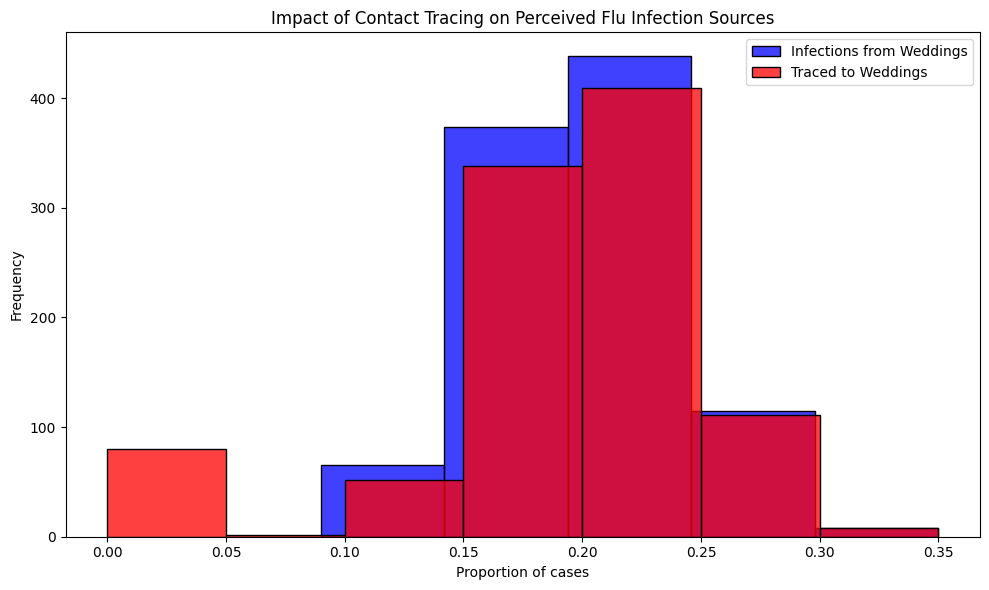

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

def simulate_event(m):
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """
  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

# Run the simulation 1000 times
results = [simulate_event(m) for m in range(1000)]
props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

# Plotting the results
plt.figure(figsize=(10, 6))
sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
sns.histplot(props_df['Traces'], color="red", alpha=0.75, binwidth=0.05, kde=False, label='Traced to Weddings')
plt.xlabel("Proportion of cases")
plt.ylabel("Frequency")
plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
plt.legend()
plt.tight_layout()
plt.show()

## 10 Repetations

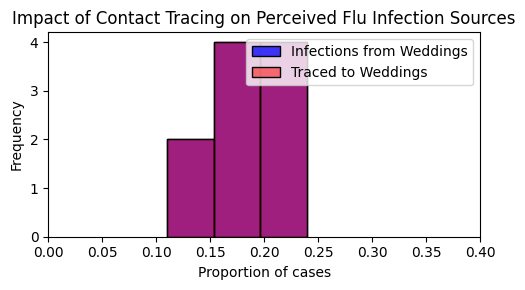

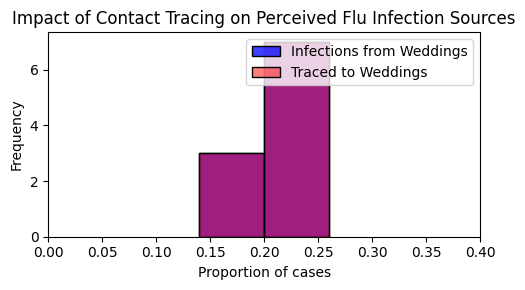

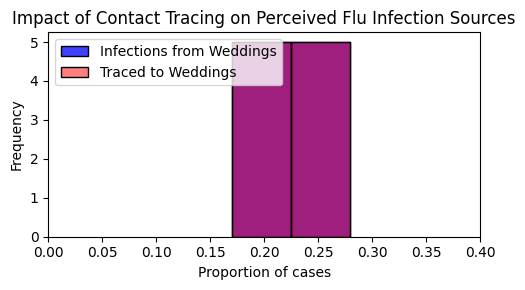

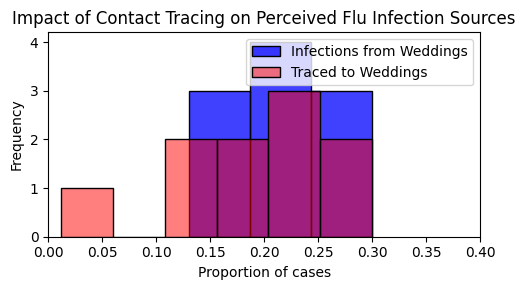

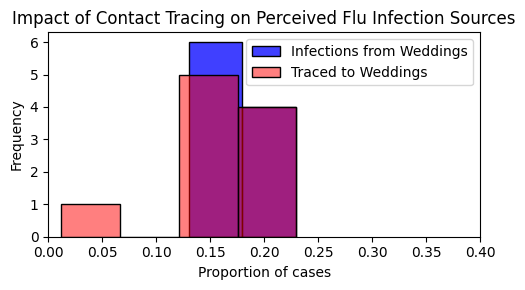

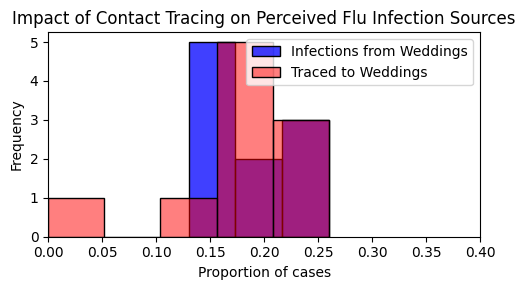

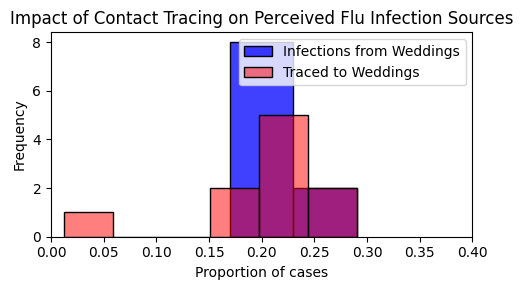

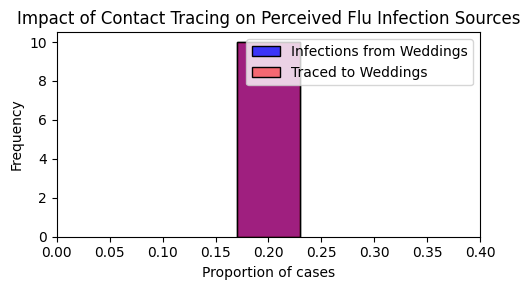

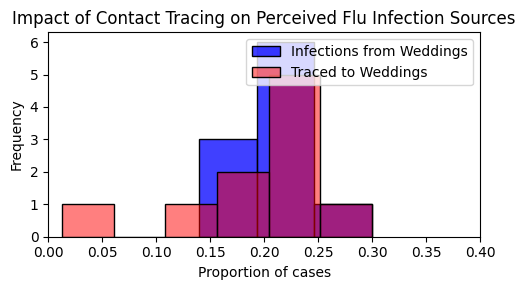

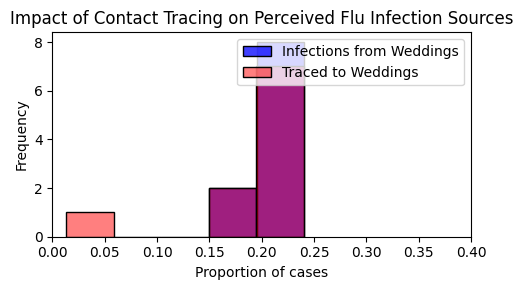

In [2]:
for dummy in range(10):
    results = [simulate_event(m) for m in range(10)]
    props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

    # Plotting the results
    plt.figure(figsize=(5, 3))
    sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
    sns.histplot(props_df['Traces'], color="red", alpha=0.5, binwidth=0.05, kde=False, label='Traced to Weddings')
    plt.xlabel("Proportion of cases")
    plt.ylabel("Frequency")
    plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
    plt.legend()
    plt.tight_layout()
    plt.xlim(0, 0.4)
    plt.show()

## 100 Repetations

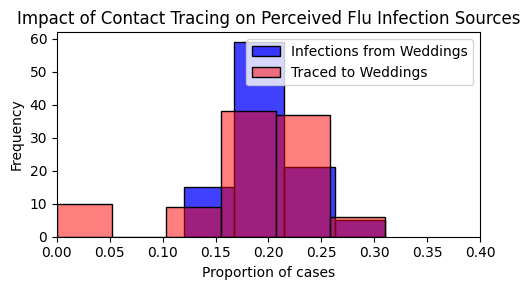

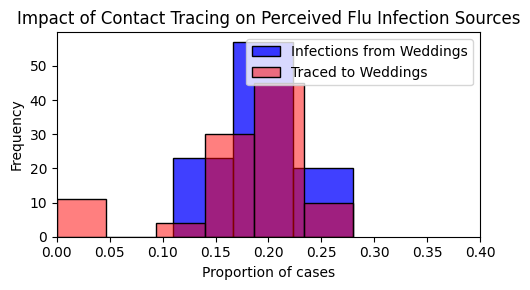

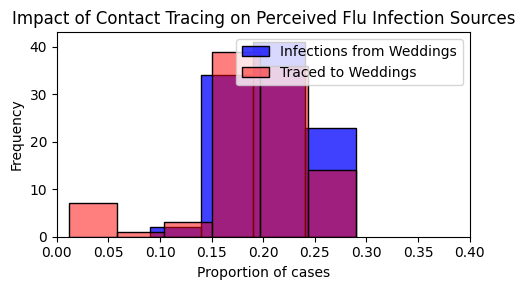

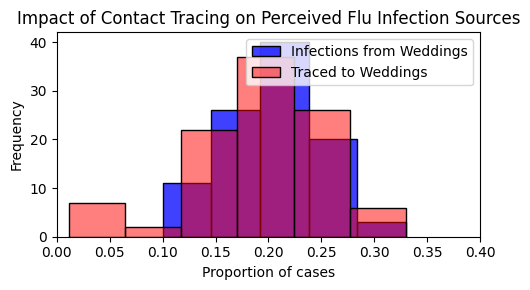

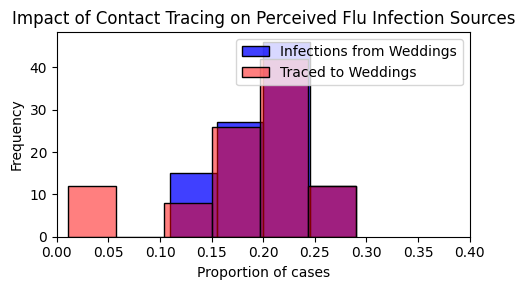

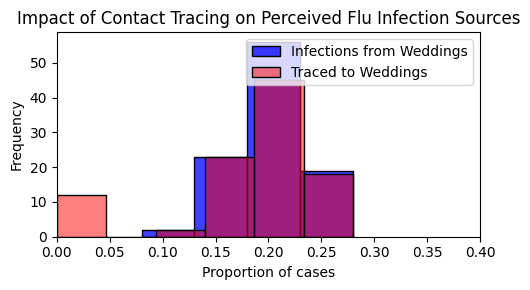

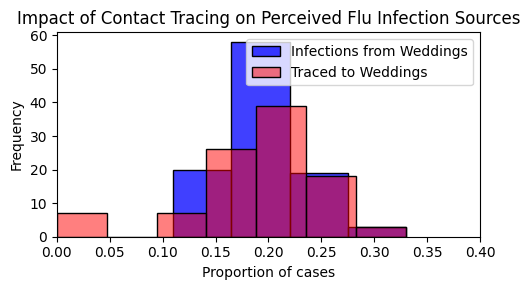

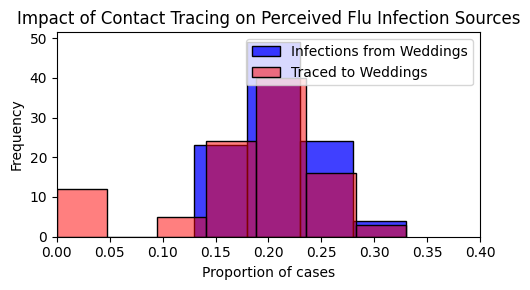

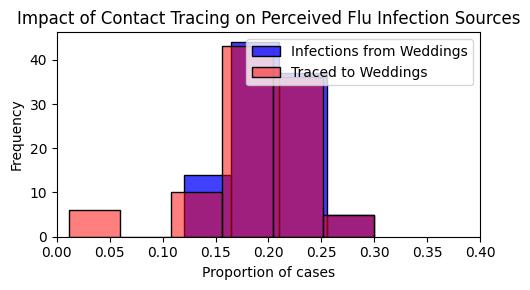

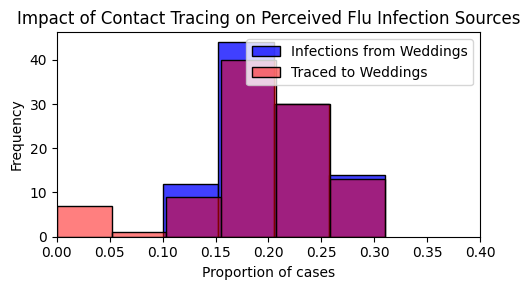

In [3]:
for dummy in range(10):
    results = [simulate_event(m) for m in range(100)]
    props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

    # Plotting the results
    plt.figure(figsize=(5, 3))
    sns.histplot(props_df['Infections'], color="blue", alpha=0.75, binwidth=0.05, kde=False, label='Infections from Weddings')
    sns.histplot(props_df['Traces'], color="red", alpha=0.5, binwidth=0.05, kde=False, label='Traced to Weddings')
    plt.xlabel("Proportion of cases")
    plt.ylabel("Frequency")
    plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
    plt.legend()
    plt.tight_layout()
    plt.xlim(0, 0.4)
    plt.show()

# Changed Code

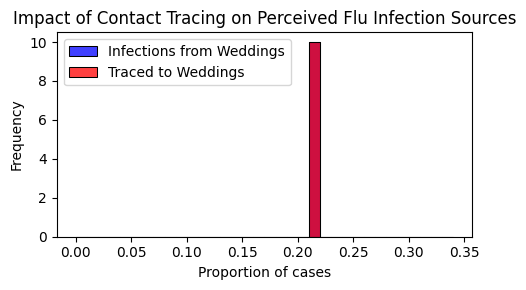

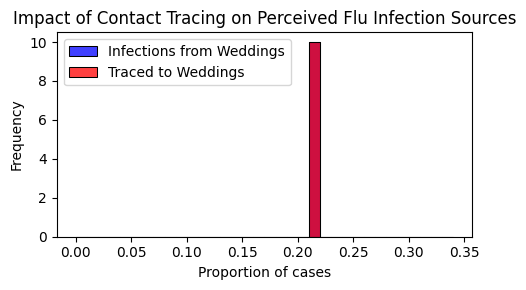

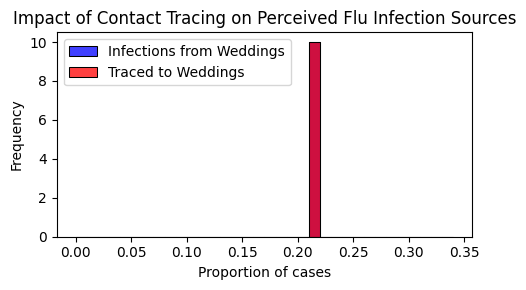

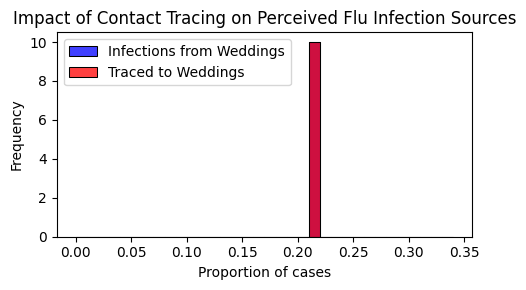

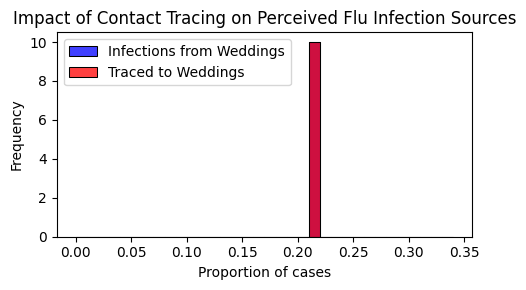

In [4]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Note: Suppressing FutureWarnings to maintain a clean output. This is specifically to ignore warnings about
# deprecated features in the libraries we're using (e.g., 'use_inf_as_na' option in Pandas, used by Seaborn),
# which we currently have no direct control over. This action is taken to ensure that our output remains
# focused on relevant information, acknowledging that we rely on external library updates to fully resolve
# these deprecations. Always consider reviewing and removing this suppression after significant library updates.
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Constants representing the parameters of the model
ATTACK_RATE = 0.10
TRACE_SUCCESS = 0.20
SECONDARY_TRACE_THRESHOLD = 2

def simulate_event_doga(random_number_generator_seed, m):
  """
  Simulates the infection and tracing process for a series of events.
  
  This function creates a DataFrame representing individuals attending weddings and brunches,
  infects a subset of them based on the ATTACK_RATE, performs primary and secondary contact tracing,
  and calculates the proportions of infections and traced cases that are attributed to weddings.
  
  Parameters:
  - random_number_generator_seed: Seed for the random number generator. For reproducibility.
  - m: Dummy parameter for iteration purposes.
  
  Returns:
  - A tuple containing the proportion of infections and the proportion of traced cases
    that are attributed to weddings.
  """

  # Set random seed for reproducibility
  np.random.seed(random_number_generator_seed)

  # Create DataFrame for people at events with initial infection and traced status
  events = ['wedding'] * 200 + ['brunch'] * 800
  ppl = pd.DataFrame({
      'event': events,
      'infected': False,
      'traced': np.nan  # Initially setting traced status as NaN
  })

  # Explicitly set 'traced' column to nullable boolean type
  ppl['traced'] = ppl['traced'].astype(pd.BooleanDtype())

  # Infect a random subset of people
  infected_indices = np.random.choice(ppl.index, size=int(len(ppl) * ATTACK_RATE), replace=False)
  ppl.loc[infected_indices, 'infected'] = True

  # Primary contact tracing: randomly decide which infected people get traced
  ppl.loc[ppl['infected'], 'traced'] = np.random.rand(sum(ppl['infected'])) < TRACE_SUCCESS

  # Secondary contact tracing based on event attendance
  event_trace_counts = ppl[ppl['traced'] == True]['event'].value_counts()
  events_traced = event_trace_counts[event_trace_counts >= SECONDARY_TRACE_THRESHOLD].index
  ppl.loc[ppl['event'].isin(events_traced) & ppl['infected'], 'traced'] = True

  # Calculate proportions of infections and traces attributed to each event type
  ppl['event_type'] = ppl['event'].str[0]  # 'w' for wedding, 'b' for brunch
  wedding_infections = sum(ppl['infected'] & (ppl['event_type'] == 'w'))
  brunch_infections = sum(ppl['infected'] & (ppl['event_type'] == 'b'))
  p_wedding_infections = wedding_infections / (wedding_infections + brunch_infections)

  wedding_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'w'))
  brunch_traces = sum(ppl['infected'] & ppl['traced'] & (ppl['event_type'] == 'b'))
  p_wedding_traces = wedding_traces / (wedding_traces + brunch_traces)

  return p_wedding_infections, p_wedding_traces

for dummy in range(5):
    random_number_generator_seed = 123
    # Run the simulation 10 times
    results = [simulate_event_doga(random_number_generator_seed, m) for m in range(10)]
    props_df = pd.DataFrame(results, columns=["Infections", "Traces"])

    # Plotting the results
    plt.figure(figsize=(5, 3))
    bins = np.arange(0, 0.35, 0.01)
    sns.histplot(props_df['Infections'], color="blue", alpha=0.75, bins=bins, kde=False, label='Infections from Weddings')
    sns.histplot(props_df['Traces'], color="red", alpha=0.75, bins=bins, kde=False, label='Traced to Weddings')
    plt.xlabel("Proportion of cases")
    plt.ylabel("Frequency")
    plt.title("Impact of Contact Tracing on Perceived Flu Infection Sources")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Criteria

|Criteria|Complete|Incomplete|
|--------|----|----|
|Alteration of the code|The code changes made, made it reproducible.|The code is still not reproducible.|
|Description of changes|The author answered questions and explained the reasonings for the changes made well.|The author did not answer questions or explain the reasonings for the changes made well.|

## Submission Information
🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `23:59 - 06 January 2026`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This markdown file (`a1_sampling_and_reproducibility.ipynb`) should be populated with the code changed.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/sampling/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

#### Checklist:
- [ ] Create a branch called `assignment-1`.
- [ ] Ensure that the repository is public.
- [ ] Review [the PR description guidelines](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md#guidelines-for-pull-request-descriptions) and adhere to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via the help channel in Slack. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.
